# quantum-solar demo

Residential battery charge/discharge scheduling under time-of-use pricing,
solved as a QUBO with QAOA and verified against exact classical baselines.

The pipeline: `BatteryProblem` -> `build_qubo` (exact slack encoding of the SoC
bounds) -> `qubo_to_ising` -> `QAOASolver`, cross-checked with `brute_force_solve`
(exact, tiny instances) and `dp_solve` (exact, scales to a full day).

In [1]:
import numpy as np

from quantum_solar import (
    synthetic_instance, build_qubo, default_weights,
    brute_force_solve, dp_solve, QAOASolver,
)
from quantum_solar.plotting import plot_schedule

%matplotlib inline

## 1. A small instance

We use a 3-slot instance so the QUBO is small enough to enumerate exactly and to
run on the Aer simulator quickly.

In [2]:
problem = synthetic_instance(num_slots=3, seed=7, capacity=3.0,
                             charge_energy=1.0, initial_soc=1.0)
weights = default_weights(problem)
qubo = build_qubo(problem, weights)

print(f"slots        : {problem.num_slots}")
print(f"QUBO vars    : {qubo.num_vars}  (2T decision bits + slack)")
print(f"prices       : {np.round(problem.price, 3)}")

slots        : 3
QUBO vars    : 10  (2T decision bits + slack)
prices       : [0.109 0.127 0.215]


## 2. Exact baselines

`brute_force_solve` enumerates the QUBO; `dp_solve` optimizes the true problem
with dynamic programming. They must agree on the optimal cost.

In [3]:
brute = brute_force_solve(problem, qubo)
dp = dp_solve(problem)

print(f"brute force : cost ${brute.true_energy:.3f}  feasible={brute.feasible}")
print(f"DP          : cost ${dp.true_energy:.3f}  feasible={dp.feasible}")
assert np.isclose(brute.true_energy, dp.true_energy)

brute force : cost $-0.026  feasible=True
DP          : cost $-0.026  feasible=True


## 3. QAOA on the Aer simulator

QAOA should recover the same optimum the exact solvers found.

In [4]:
result = QAOASolver(reps=3, n_starts=5, shots=4096, seed=1234).solve(problem, qubo)

print(f"QAOA        : cost ${result.true_energy:.3f}  feasible={result.feasible}")
c, d = problem.decode(result.x)
print(f"charge bits : {c}")
print(f"discharge   : {d}")
assert np.isclose(result.true_energy, dp.true_energy)

QAOA        : cost $-0.026  feasible=True
charge bits : [1 0 0]
discharge   : [0 0 1]


## 4. A full-day schedule (synthetic)

The DP solver scales, so we can plan an entire day and visualize the schedule.

daily cost  : $-0.06


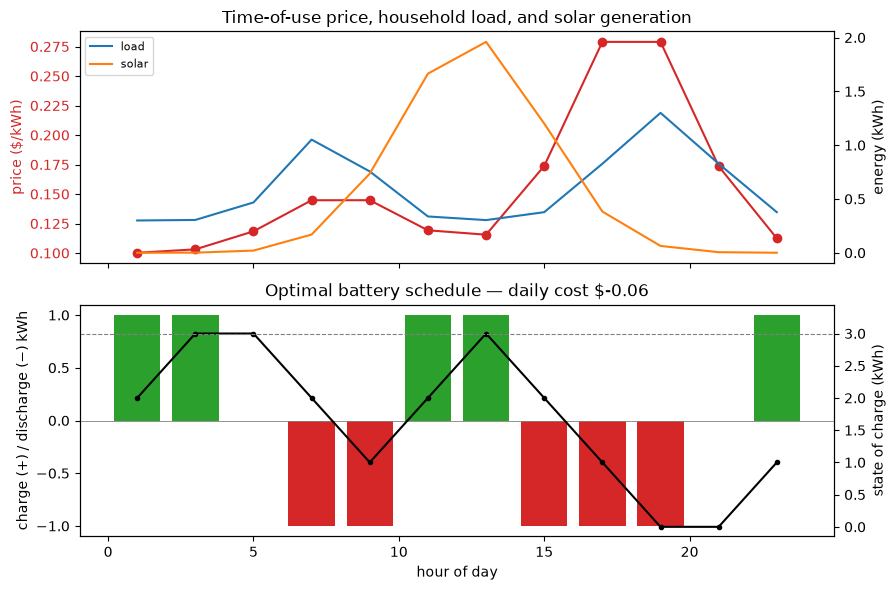

In [5]:
day = synthetic_instance(num_slots=12, seed=1, noise=0.0)
day_solution = dp_solve(day)
print(f"daily cost  : ${day_solution.true_energy:.2f}")

fig = plot_schedule(day, day_solution)

## 5. Real data: all three inputs

`load_nrel_instance` now uses three real inputs, all coherent for Golden, CO:
solar generation (NREL PVWatts), time-of-use price (Xcel Energy Colorado
Residential RE-TOU via URDB), and household load (NREL ResStock representative
Colorado single-family-detached summer-weekday profile). Requires `NREL_API_KEY`.

Text(0.5, 1.0, 'Real data: NREL PVWatts (Golden CO) + Xcel CO RE-TOU + NREL ResStock load, summer weekday')

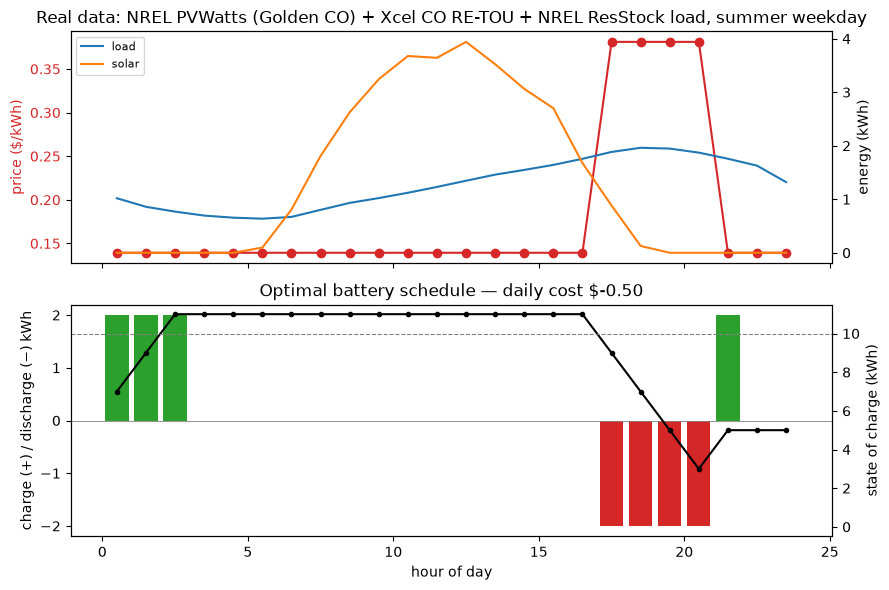

In [6]:
from quantum_solar.data import load_nrel_instance

real = load_nrel_instance(lat=39.74, lon=-105.18, day=172)  # Golden, CO; summer
real_solution = dp_solve(real)

fig = plot_schedule(real, real_solution)
fig.axes[0].set_title(
    "Real data: NREL PVWatts (Golden CO) + Xcel CO RE-TOU + NREL ResStock load, summer weekday"
)

### Dollar savings (typical summer weekday)

A three-way comparison for one representative summer weekday. "No system" is the
house on the TOU tariff with no solar and no battery; "solar, battery idle" adds
solar but never cycles the battery (identical to having no battery under this
net-metered model); "solar + DP-optimal battery" schedules the battery optimally.

In [7]:
no_system = float(real.price @ real.load)                       # no solar, no battery
solar_idle = float(real.price @ (real.load - real.generation))  # solar, battery idle (= no battery)
dp_cost = real_solution.true_energy                             # solar + DP-optimal battery

print(f"load {real.load.sum():.1f} kWh/day   solar {real.generation.sum():.1f} kWh/day")
print()
print(f"  no system (no solar, no battery)     ${no_system:6.2f}")
print(f"  solar, battery idle (= no battery)   ${solar_idle:6.2f}")
print(f"  solar + DP-optimal battery           ${dp_cost:6.2f}")
print()
print(f"  solar saves                          ${no_system - solar_idle:5.2f}/day")
print(f"  optimal battery scheduling adds      ${solar_idle - dp_cost:5.2f}/day  (price arbitrage)")
print(f"  TOTAL vs no system                   ${no_system - dp_cost:5.2f}/day")
print()
print("Typical summer weekday only, NOT annualized. Annual figures would need")
print("representative days across seasons (winter TOU prices in our URDB fixture")
print("are lower). The battery's scheduling saving is pure price arbitrage and is")
print("independent of the load level; the real load makes the bill and solar")
print("self-consumption numbers honest.")

load 30.5 kWh/day   solar 31.8 kWh/day

  no system (no solar, no battery)     $  6.11
  solar, battery idle (= no battery)   $  1.43
  solar + DP-optimal battery           $ -0.50

  solar saves                          $ 4.68/day
  optimal battery scheduling adds      $ 1.93/day  (price arbitrage)
  TOTAL vs no system                   $ 6.61/day

Typical summer weekday only, NOT annualized. Annual figures would need
representative days across seasons (winter TOU prices in our URDB fixture
are lower). The battery's scheduling saving is pure price arbitrage and is
independent of the load level; the real load makes the bill and solar
self-consumption numbers honest.
